In [ ]:
%run etl.ipynb
%run eda.ipynb
%run dataset.ipynb
%run loss.ipynb
%run train.ipynb

In [ ]:
import torch

radiopedia: OK (829 muestras, (512, 512))
medseg: OK (100 muestras, (512, 512))
--- train ---
Imágenes: (80, 512, 512, 1), dtype=float32, min=-1606.522, max=597.805
Máscaras: (80, 512, 512, 4), dtype=float32, min=0.000, max=1.000
Número de clases en máscara: 4
Imágenes sin lesión: 0/80 (0.0%)


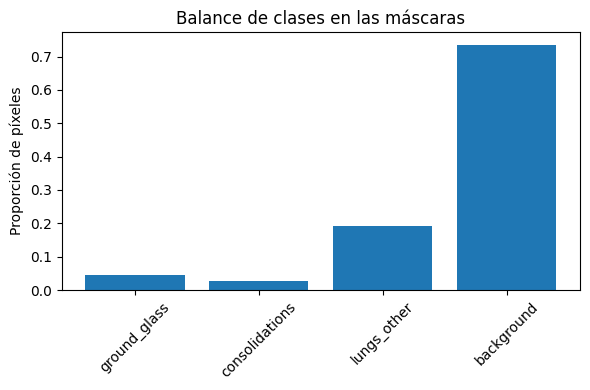

ground_glass: 4.6429%
consolidations: 2.6484%
lungs_other: 19.1021%
background: 73.6067%


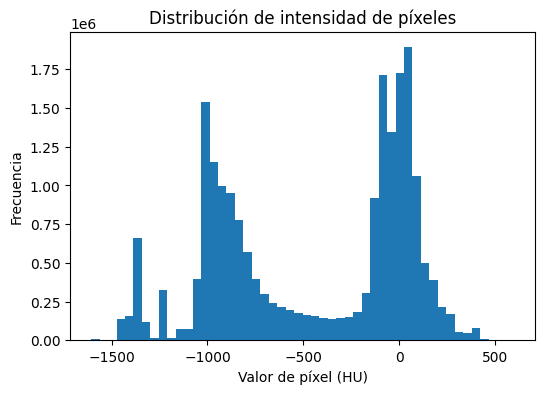

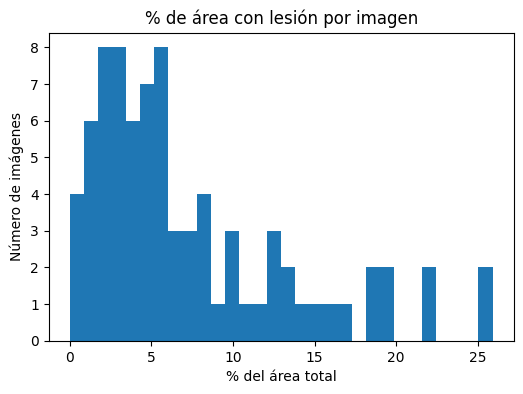

Media: 7.29%, mediana: 5.23%, max: 25.90%
Componentes por imagen -> media: 7.65, max: 34


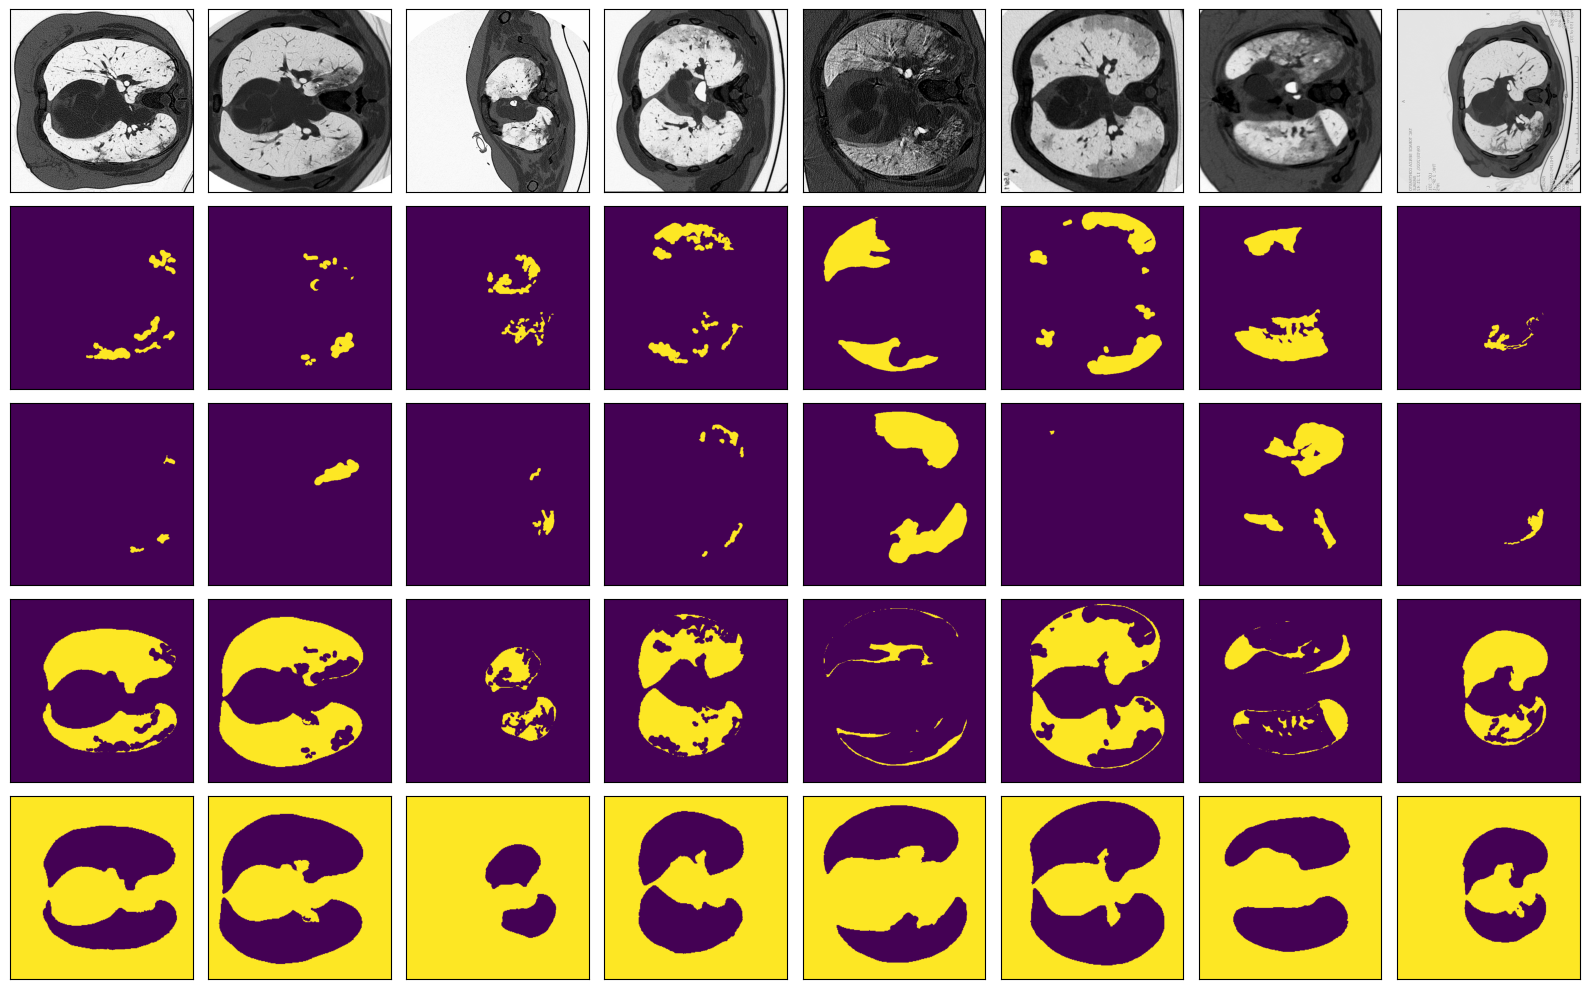

In [30]:
etl_output = run_etl()
eda_output = run_eda(
    etl_output["train_images"],
    etl_output["train_masks"],
    name="train",
    class_names=["ground_glass", "consolidations", "lungs_other", "background"]
)

In [ ]:
# Hyperparameters
LEARNING_RATE = 1e-4
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 32
NUM_EPOCHS = 3
NUM_WORKERS = 2
IMAGE_HEIGTH = 160
IMAGE_WIDTH = 240
PIN_MEMORY = True
LOAD_MODEL = False

In [31]:
train_images, train_masks = etl_output["train_images"], etl_output["train_masks"]
val_images, val_masks = etl_output["val_images"], etl_output["val_masks"]
images_radiopedia, masks_radiopedia = etl_output["images_radiopedia"], etl_output["masks_radiopedia"]
test_images_medseg = etl_output["test_images_medseg"]

In [32]:
train_statistics = image_statistics(train_images)

In [33]:
BATCH_SIZE = 32
transformer = Transformer(statistics=train_statistics)

train_dataset = CovidDataset(train_images, train_masks, transformer.train())
val_dataset = CovidDataset(val_images, val_masks, transformer.validation())       

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Referencia
[PyTorch Image Segmentation Tutorial with U-NET: everything from scratch baby](https://www.youtube.com/watch?v=IHq1t7NxS8k)

[PyTorch Segmentation Models — A Practical Guide](https://medium.com/@heyamit10/pytorch-segmentation-models-a-practical-guide-5bf973a32e30)